In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/job_salary.csv')
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.describe()

(250000, 10)
job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
remote_work         object
certifications       int64
salary               int64
dtype: object
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


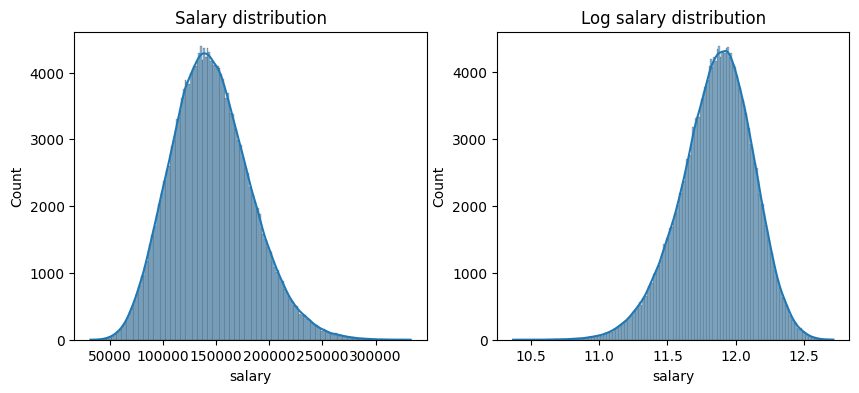

In [3]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['salary'], kde=True)
plt.title('Salary distribution')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['salary']), kde=True)
plt.title('Log salary distribution')
plt.show()

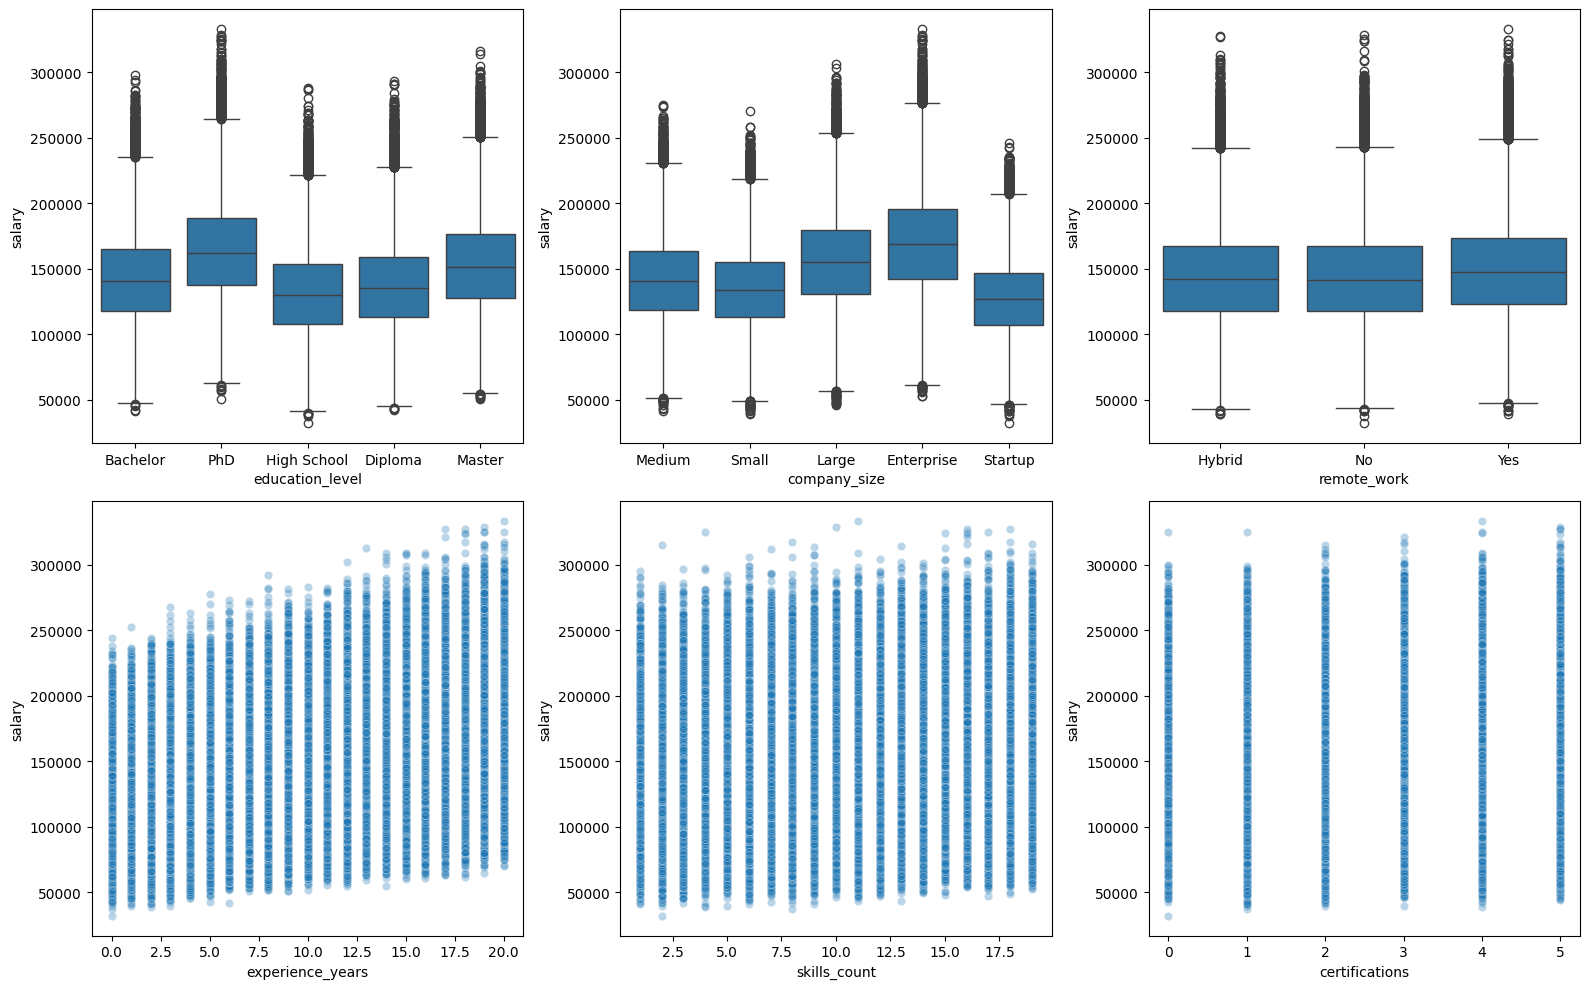

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))

sns.boxplot(data=df, x='education_level', y='salary', ax=axes[0,0])
sns.boxplot(data=df, x='company_size', y='salary', ax=axes[0,1])
sns.boxplot(data=df, x='remote_work', y='salary', ax=axes[0,2])
sns.scatterplot(data=df, x='experience_years', y='salary', ax=axes[1,0], alpha=0.3)
sns.scatterplot(data=df, x='skills_count', y='salary', ax=axes[1,1], alpha=0.3)
sns.scatterplot(data=df, x='certifications', y='salary', ax=axes[1,2], alpha=0.3)
plt.tight_layout()
plt.show()

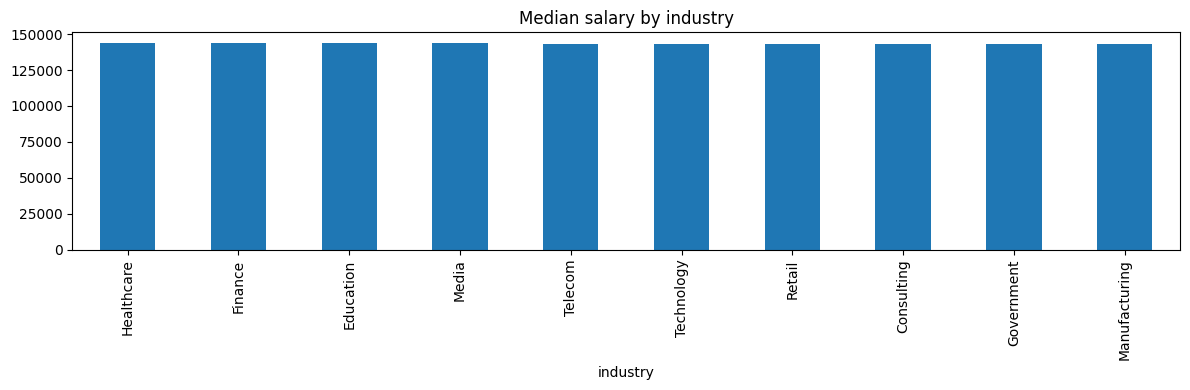

In [5]:
df.groupby('industry')['salary'].median().sort_values(ascending=False).plot(kind='bar', figsize=(12,4))
plt.title('Median salary by industry')
plt.tight_layout()
plt.show()

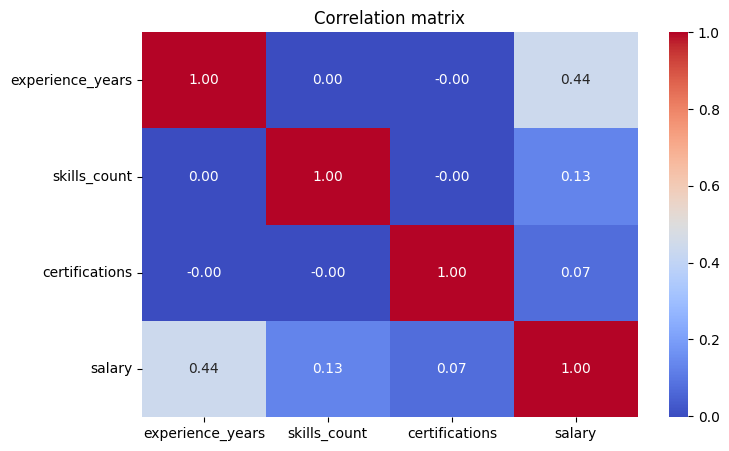

In [6]:
numeric_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(8,5))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()